# 03 — Model Training & Evaluation

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook trains Naive, Random Forest, XGBoost, and LightGBM models with Optuna hyperparameter tuning,
using rolling forecast origin (expanding window) validation with 3 folds of 30 days each.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import optuna
from style_config import (apply_style, PRIMARY, ACCENT, NEUTRAL, SECONDARY, ALERT,
                          get_model_color, get_model_colors)

%matplotlib inline

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning)

BASE_DIR = Path(".")
INPUT_PATH = BASE_DIR / 'output' / 'processed' / 'features.parquet'
MODEL_DIR = BASE_DIR / 'output' / 'models'
PLOT_DIR = BASE_DIR / 'output' / 'models' / 'plots'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()

def save_fig(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'   \u2192 Saved {name}.png')

TARGET = 'udsVenta'
EXCLUDE = ['producto', 'idSecuencia', 'fecha', 'day_name', TARGET,
           'prod_mean_sales', 'prod_std_sales', 'prod_median_sales']

N_FOLDS = 3
FOLD_DAYS = 30
N_OPTUNA_TRIALS = 30
N_TUNE_PRODUCTS = 50


## 1. Load Data


In [2]:
print('=' * 60)
print('1. LOADING DATA')
print('=' * 60)

df = pd.read_parquet(INPUT_PATH)
df = df.sort_values(['producto', 'fecha']).reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in EXCLUDE]
print(f'Shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f"Date range: {df['fecha'].min().date()} \u2192 {df['fecha'].max().date()}")


1. LOADING DATA


Shape: (605283, 41)
Features: 33
Date range: 2024-04-19 → 2026-03-22


## 2. Rolling Forecast Origin Splits

Create 3 test windows of 30 days each, working backwards from the end of the dataset.


In [3]:
print('\n' + '=' * 60)
print('2. ROLLING FORECAST ORIGIN SPLITS')
print('=' * 60)

all_dates = sorted(df['fecha'].unique())
max_date = all_dates[-1]

folds = []
for i in range(N_FOLDS):
    test_end = all_dates[-(i * FOLD_DAYS + 1)] if i > 0 else max_date
    test_end_idx = all_dates.index(test_end) if test_end in all_dates else len(all_dates) - 1 - i * FOLD_DAYS
    test_start_idx = max(0, test_end_idx - FOLD_DAYS + 1)
    test_dates = all_dates[test_start_idx:test_end_idx + 1]
    train_dates = all_dates[:test_start_idx]
    if len(train_dates) > 0 and len(test_dates) > 0:
        folds.append({
            'fold': N_FOLDS - i,
            'train_end': train_dates[-1],
            'test_start': test_dates[0],
            'test_end': test_dates[-1],
            'n_train_days': len(train_dates),
            'n_test_days': len(test_dates)
        })

folds = list(reversed(folds))
for f in folds:
    print(f"  Fold {f['fold']}: train\u2192{pd.Timestamp(f['train_end']).date()} | "
          f"test {pd.Timestamp(f['test_start']).date()}\u2192{pd.Timestamp(f['test_end']).date()} "
          f"({f['n_test_days']}d)")



2. ROLLING FORECAST ORIGIN SPLITS
  Fold 1: train→2025-12-22 | test 2025-12-23→2026-01-21 (30d)
  Fold 2: train→2026-01-21 | test 2026-01-22→2026-02-20 (30d)
  Fold 3: train→2026-02-20 | test 2026-02-21→2026-03-22 (30d)


## 3–4. Metrics Definition & Naive Baseline

Define the evaluation metrics (MAE, RMSE, MAPE, σ_e) and compute the naive lag-7 baseline.


In [4]:
def calc_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    errors = y_true - y_pred
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs(errors[mask] / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    sigma_e = np.std(errors)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sigma_e': sigma_e}

print('\n' + '=' * 60)
print('4. NAIVE BASELINE (lag_7 = same weekday last week)')
print('=' * 60)

naive_results = []
for fold in folds:
    test_mask = (df['fecha'] >= fold['test_start']) & (df['fecha'] <= fold['test_end'])
    test = df[test_mask]
    y_true = test[TARGET].values
    y_pred = test['lag_7'].values
    m = calc_metrics(y_true, y_pred)
    m['fold'] = fold['fold']
    m['model'] = 'Naive_lag7'
    naive_results.append(m)
    print(f"  Fold {fold['fold']}: MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  MAPE={m['MAPE']:.1f}%  \u03c3_e={m['sigma_e']:.3f}")



4. NAIVE BASELINE (lag_7 = same weekday last week)
  Fold 1: MAE=1.436  RMSE=2.545  MAPE=78.7%  σ_e=2.545
  Fold 2: MAE=1.347  RMSE=2.366  MAPE=75.3%  σ_e=2.366
  Fold 3: MAE=1.256  RMSE=2.277  MAPE=74.4%  σ_e=2.277


## 5. Hyperparameter Tuning (Optuna)

Tune LightGBM, XGBoost, and Random Forest using Optuna (30 trials each) on a subset of 50 products.
This step takes approximately 5–10 minutes.


In [5]:
print('\n' + '=' * 60)
print('5. HYPERPARAMETER TUNING (Optuna)')
print('=' * 60)

np.random.seed(42)
tune_products = np.random.choice(df['producto'].unique(), size=N_TUNE_PRODUCTS, replace=False)
tune_fold = folds[0]

tune_train_mask = df['fecha'] <= tune_fold['train_end']
tune_test_mask = (df['fecha'] >= tune_fold['test_start']) & (df['fecha'] <= tune_fold['test_end'])

tune_train = df[tune_train_mask & df['producto'].isin(tune_products)]
tune_test = df[tune_test_mask & df['producto'].isin(tune_products)]

X_tune_train = tune_train[feature_cols]
y_tune_train = tune_train[TARGET]
X_tune_test = tune_test[feature_cols]
y_tune_test = tune_test[TARGET]

print(f'Tuning on {N_TUNE_PRODUCTS} products, fold 1')
print(f'Tune train: {len(tune_train):,} rows | Tune test: {len(tune_test):,} rows')

# ── LightGBM tuning ──
print('\n── Tuning LightGBM ──')

def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'verbose': -1, 'n_jobs': -1, 'random_state': 42
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tune_train, y_tune_train)
    preds = model.predict(X_tune_test).clip(0)
    return np.sqrt(mean_squared_error(y_tune_test, preds))

lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
lgb_best = lgb_study.best_params
lgb_best.update({'verbose': -1, 'n_jobs': -1, 'random_state': 42})
print(f'Best RMSE: {lgb_study.best_value:.4f}')

# ── XGBoost tuning ──
print('\n── Tuning XGBoost ──')

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'n_jobs': -1, 'random_state': 42, 'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tune_train, y_tune_train)
    preds = model.predict(X_tune_test).clip(0)
    return np.sqrt(mean_squared_error(y_tune_test, preds))

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
xgb_best = xgb_study.best_params
xgb_best.update({'n_jobs': -1, 'random_state': 42, 'verbosity': 0})
print(f'Best RMSE: {xgb_study.best_value:.4f}')

# ── Random Forest tuning ──
print('\n── Tuning Random Forest ──')

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'n_jobs': -1, 'random_state': 42
    }
    model = RandomForestRegressor(**params)
    model.fit(X_tune_train, y_tune_train)
    preds = model.predict(X_tune_test).clip(0)
    return np.sqrt(mean_squared_error(y_tune_test, preds))

rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
rf_best = rf_study.best_params
rf_best.update({'n_jobs': -1, 'random_state': 42})
print(f'Best RMSE: {rf_study.best_value:.4f}')

tuned_params = {'lgb': lgb_best, 'xgb': xgb_best, 'rf': rf_best}
with open(MODEL_DIR / 'tuned_params.json', 'w') as f:
    json.dump(tuned_params, f, indent=2, default=str)
print(f'\n\u2713 Saved tuned_params.json')



5. HYPERPARAMETER TUNING (Optuna)


Tuning on 50 products, fold 1
Tune train: 30,650 rows | Tune test: 1,500 rows

── Tuning LightGBM ──


Best RMSE: 1.7791

── Tuning XGBoost ──


Best RMSE: 1.7823

── Tuning Random Forest ──


Best RMSE: 1.7860

✓ Saved tuned_params.json


## 6. Rolling Validation — All Models

Train Random Forest, XGBoost, and LightGBM on each fold using the tuned hyperparameters.


In [6]:
print('\n' + '=' * 60)
print('6. ROLLING VALIDATION \u2014 ALL MODELS')
print('=' * 60)

all_results = list(naive_results)
all_predictions = []

for fold in folds:
    print(f"\n\u2500\u2500 Fold {fold['fold']} \u2500\u2500")
    train_mask = df['fecha'] <= fold['train_end']
    test_mask = (df['fecha'] >= fold['test_start']) & (df['fecha'] <= fold['test_end'])
    train = df[train_mask]
    test = df[test_mask]
    X_train = train[feature_cols]
    y_train = train[TARGET]
    X_test = test[feature_cols]
    y_test = test[TARGET]
    print(f'  Train: {len(train):,} | Test: {len(test):,}')

    # Random Forest
    t0 = time.time()
    rf_model = RandomForestRegressor(**rf_best)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test).clip(0)
    rf_time = time.time() - t0
    m = calc_metrics(y_test, rf_preds)
    m.update({'fold': fold['fold'], 'model': 'RandomForest', 'time_s': rf_time})
    all_results.append(m)
    print(f"  RF:   MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  MAPE={m['MAPE']:.1f}%  \u03c3_e={m['sigma_e']:.3f}  ({rf_time:.0f}s)")

    # XGBoost
    t0 = time.time()
    xgb_model = xgb.XGBRegressor(**xgb_best)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test).clip(0)
    xgb_time = time.time() - t0
    m = calc_metrics(y_test, xgb_preds)
    m.update({'fold': fold['fold'], 'model': 'XGBoost', 'time_s': xgb_time})
    all_results.append(m)
    print(f"  XGB:  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  MAPE={m['MAPE']:.1f}%  \u03c3_e={m['sigma_e']:.3f}  ({xgb_time:.0f}s)")

    # LightGBM
    t0 = time.time()
    lgb_model = lgb.LGBMRegressor(**lgb_best)
    lgb_model.fit(X_train, y_train)
    lgb_preds = lgb_model.predict(X_test).clip(0)
    lgb_time = time.time() - t0
    m = calc_metrics(y_test, lgb_preds)
    m.update({'fold': fold['fold'], 'model': 'LightGBM', 'time_s': lgb_time})
    all_results.append(m)
    print(f"  LGBM: MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  MAPE={m['MAPE']:.1f}%  \u03c3_e={m['sigma_e']:.3f}  ({lgb_time:.0f}s)")

    if fold['fold'] == N_FOLDS:
        pred_df = test[['producto', 'fecha', TARGET, 'en_promo']].copy()
        pred_df['Naive_lag7'] = test['lag_7'].values
        pred_df['RandomForest'] = rf_preds
        pred_df['XGBoost'] = xgb_preds
        pred_df['LightGBM'] = lgb_preds
        all_predictions.append(pred_df)



6. ROLLING VALIDATION — ALL MODELS

── Fold 1 ──


  Train: 527,793 | Test: 25,830


  RF:   MAE=1.271  RMSE=1.862  MAPE=51.3%  σ_e=1.861  (1128s)


  XGB:  MAE=1.287  RMSE=1.858  MAPE=51.2%  σ_e=1.857  (9s)


  LGBM: MAE=1.288  RMSE=1.858  MAPE=50.8%  σ_e=1.855  (9s)

── Fold 2 ──


...

  XGB:  MAE=1.189  RMSE=1.728  MAPE=49.0%  σ_e=1.726  (2s)


  LGBM: MAE=1.184  RMSE=1.727  MAPE=49.4%  σ_e=1.725  (2s)

── Fold 3 ──
  Train: 579,453 | Test: 25,830


  RF:   MAE=1.098  RMSE=1.637  MAPE=50.0%  σ_e=1.636  (62s)


  XGB:  MAE=1.121  RMSE=1.635  MAPE=50.0%  σ_e=1.634  (3s)


  LGBM: MAE=1.097  RMSE=1.633  MAPE=51.5%  σ_e=1.633  (2s)


## 7. Results Summary

Average metrics across all folds and per-fold detail.


In [7]:
print('\n' + '=' * 60)
print('7. RESULTS SUMMARY')
print('=' * 60)

results_df = pd.DataFrame(all_results)
summary = results_df.groupby('model')[['MAE', 'RMSE', 'MAPE', 'sigma_e']].mean()
summary = summary.sort_values('RMSE')
print('\n\u2500\u2500 Average Metrics Across Folds \u2500\u2500')
print(summary.round(4).to_string())

print('\n\u2500\u2500 Per-Fold Detail \u2500\u2500')
pivot = results_df.pivot(index='fold', columns='model', values='RMSE')
print(pivot.round(4).to_string())

results_df.to_csv(MODEL_DIR / 'results_all_folds.csv', index=False)
summary.to_csv(MODEL_DIR / 'results_summary.csv')
print(f'\n\u2713 Saved results_all_folds.csv and results_summary.csv')

if all_predictions:
    pred_final = pd.concat(all_predictions, ignore_index=True)
    pred_final.to_parquet(MODEL_DIR / 'predictions_last_fold.parquet', index=False)
    print(f'\u2713 Saved predictions_last_fold.parquet ({len(pred_final):,} rows)')



7. RESULTS SUMMARY

── Average Metrics Across Folds ──
                 MAE    RMSE     MAPE  sigma_e
model                                         
LightGBM      1.1897  1.7392  50.5350   1.7376
XGBoost       1.1988  1.7403  50.0613   1.7391
RandomForest  1.1794  1.7424  50.1606   1.7415
Naive_lag7    1.3467  2.3960  76.1235   2.3959

── Per-Fold Detail ──
model  LightGBM  Naive_lag7  RandomForest  XGBoost
fold                                              
1        1.8577      2.5455        1.8619   1.8582
2        1.7271      2.3661        1.7286   1.7280
3        1.6327      2.2766        1.6366   1.6347



✓ Saved results_all_folds.csv and results_summary.csv
✓ Saved predictions_last_fold.parquet (25,830 rows)


## 8. Promo vs Non-Promo Performance


In [8]:
print('\n' + '=' * 60)
print('8. PROMO vs NON-PROMO PERFORMANCE')
print('=' * 60)

if all_predictions:
    pf = pred_final.copy()
    models = ['Naive_lag7', 'RandomForest', 'XGBoost', 'LightGBM']
    for label, mask in [('Non-Promo', pf['en_promo'] == 0), ('Promo', pf['en_promo'] == 1)]:
        subset = pf[mask]
        if len(subset) == 0:
            continue
        print(f'\n\u2500\u2500 {label} ({len(subset):,} rows) \u2500\u2500')
        for model in models:
            m = calc_metrics(subset[TARGET], subset[model])
            print(f"  {model:15s}: MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  MAPE={m['MAPE']:.1f}%  \u03c3_e={m['sigma_e']:.3f}")



8. PROMO vs NON-PROMO PERFORMANCE

── Non-Promo (20,286 rows) ──
  Naive_lag7     : MAE=1.237  RMSE=2.288  MAPE=74.2%  σ_e=2.288
  RandomForest   : MAE=1.086  RMSE=1.644  MAPE=50.2%  σ_e=1.643
  XGBoost        : MAE=1.107  RMSE=1.641  MAPE=50.3%  σ_e=1.640
  LightGBM       : MAE=1.079  RMSE=1.639  MAPE=52.0%  σ_e=1.639

── Promo (5,544 rows) ──
  Naive_lag7     : MAE=1.326  RMSE=2.233  MAPE=74.9%  σ_e=2.233
  RandomForest   : MAE=1.142  RMSE=1.611  MAPE=49.5%  σ_e=1.611
  XGBoost        : MAE=1.171  RMSE=1.610  MAPE=49.0%  σ_e=1.610
  LightGBM       : MAE=1.161  RMSE=1.609  MAPE=49.5%  σ_e=1.609


## 9. Plots

Model comparison bar chart, LightGBM feature importance, and actual vs predicted scatter.



9. GENERATING PLOTS


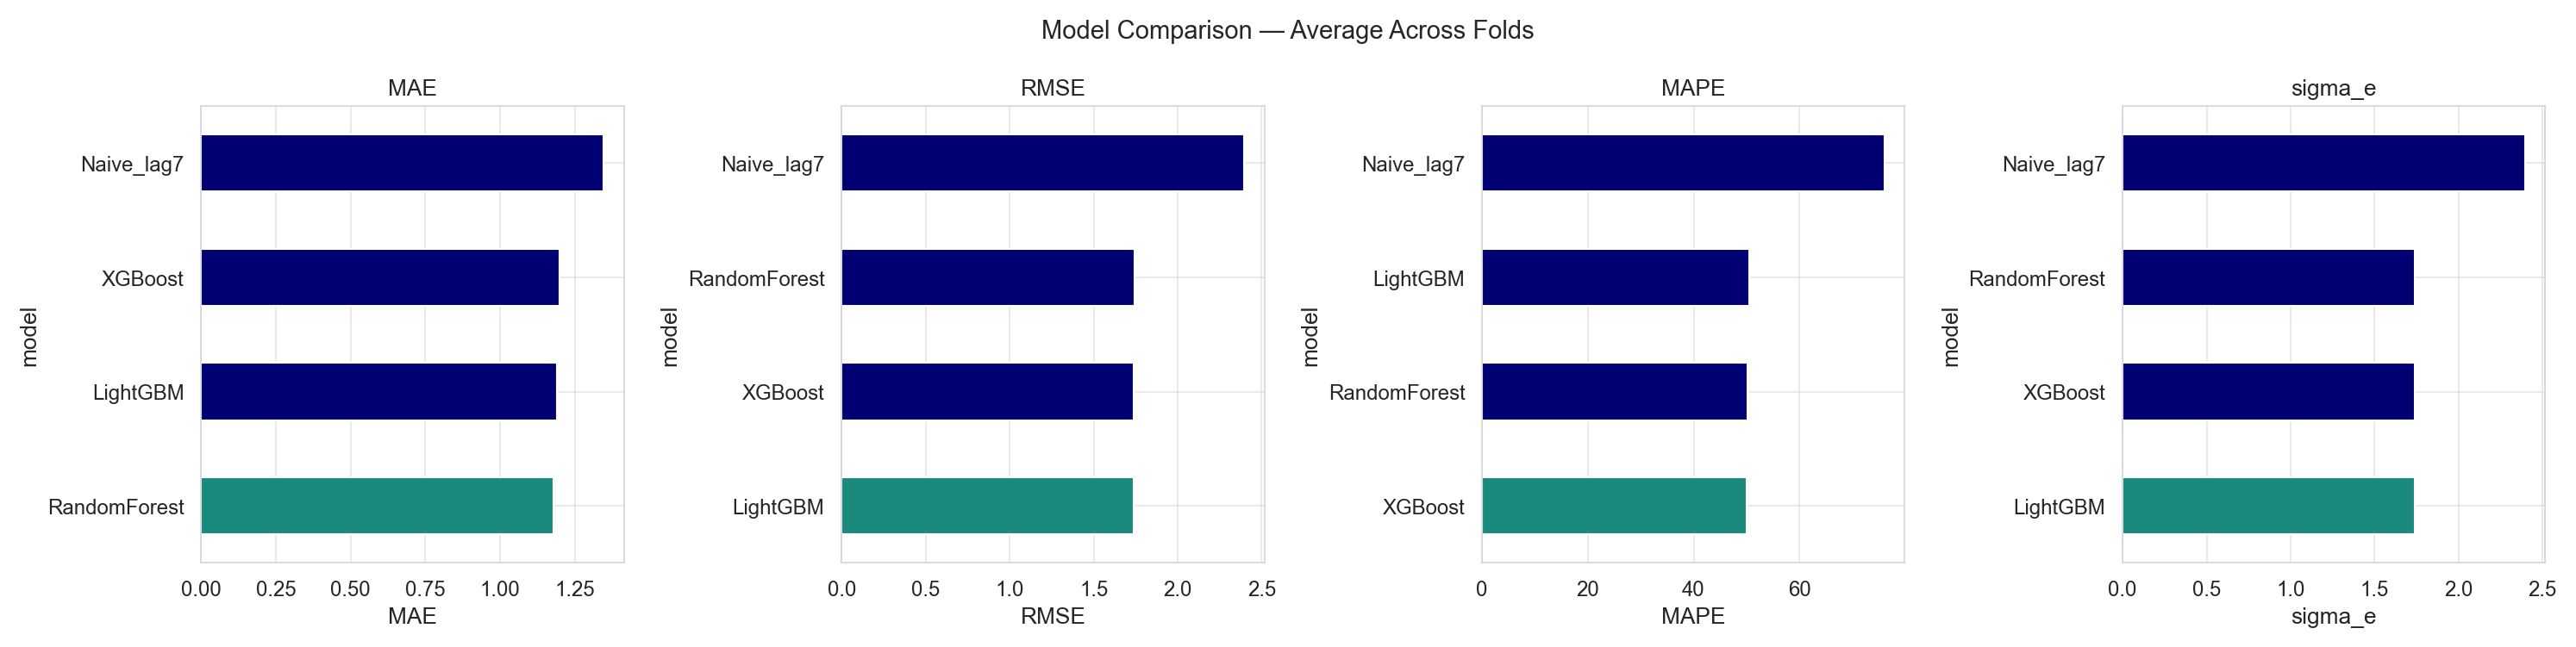

   → Saved 11_model_comparison.png


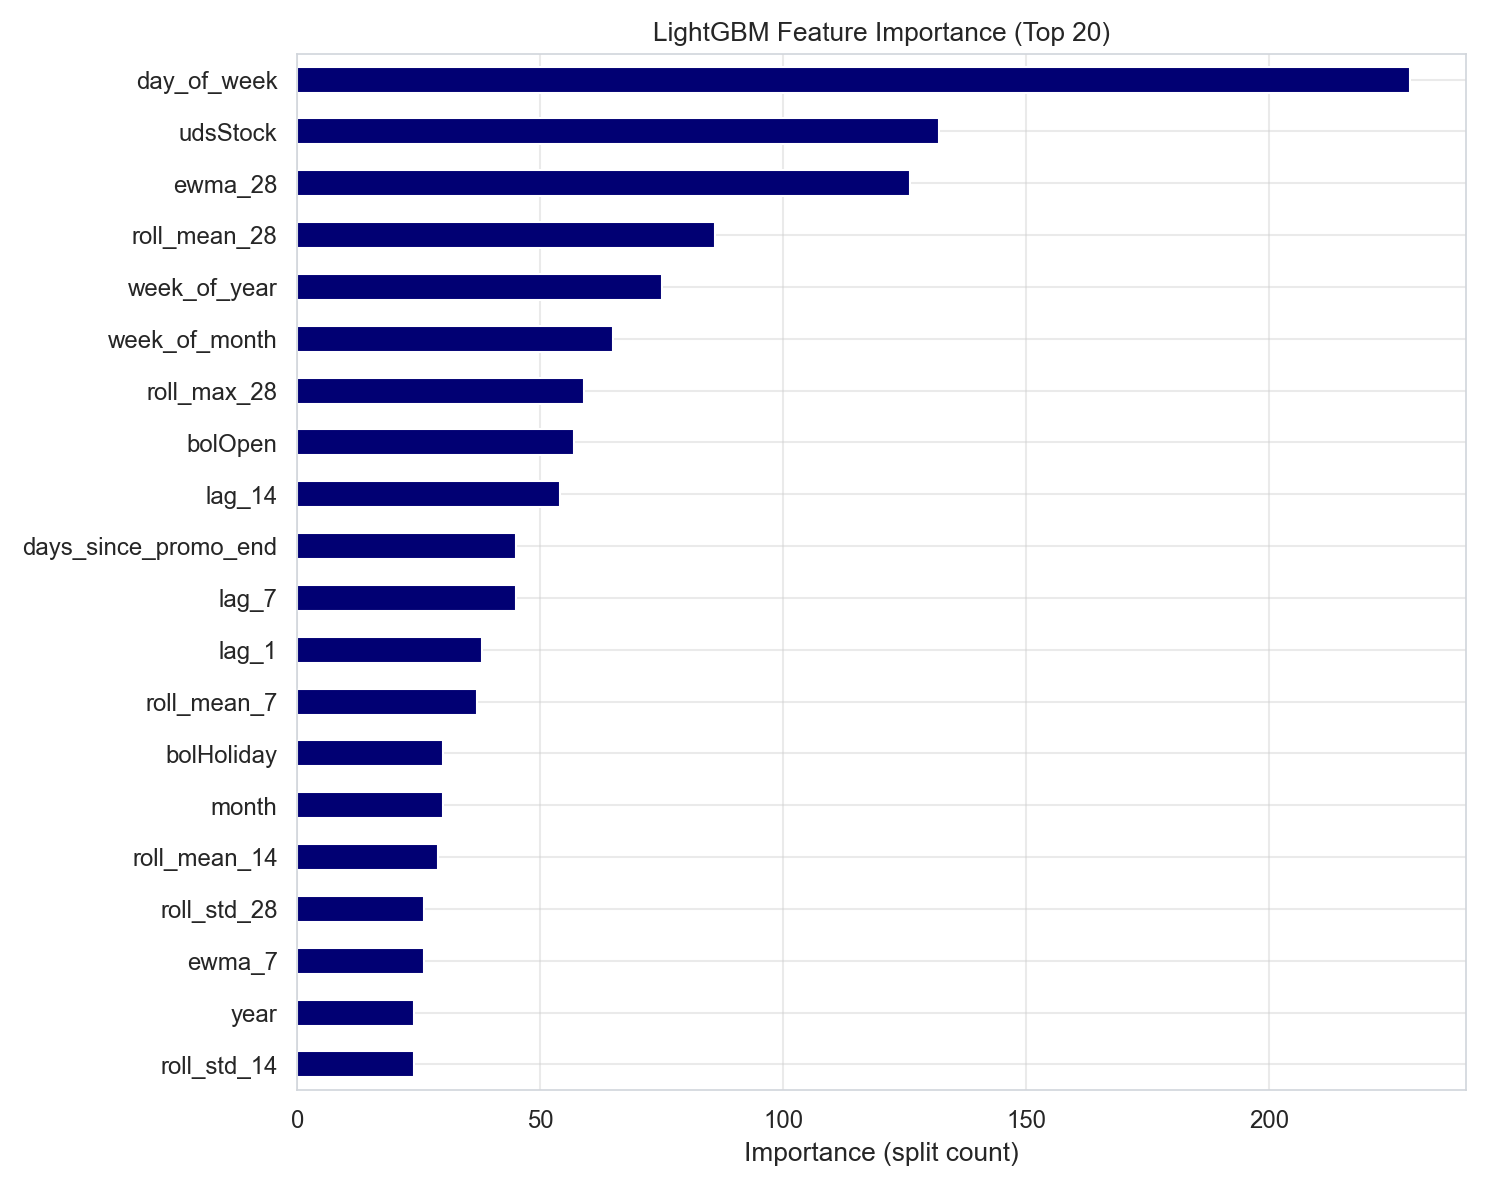

   → Saved 12_lgbm_feature_importance.png


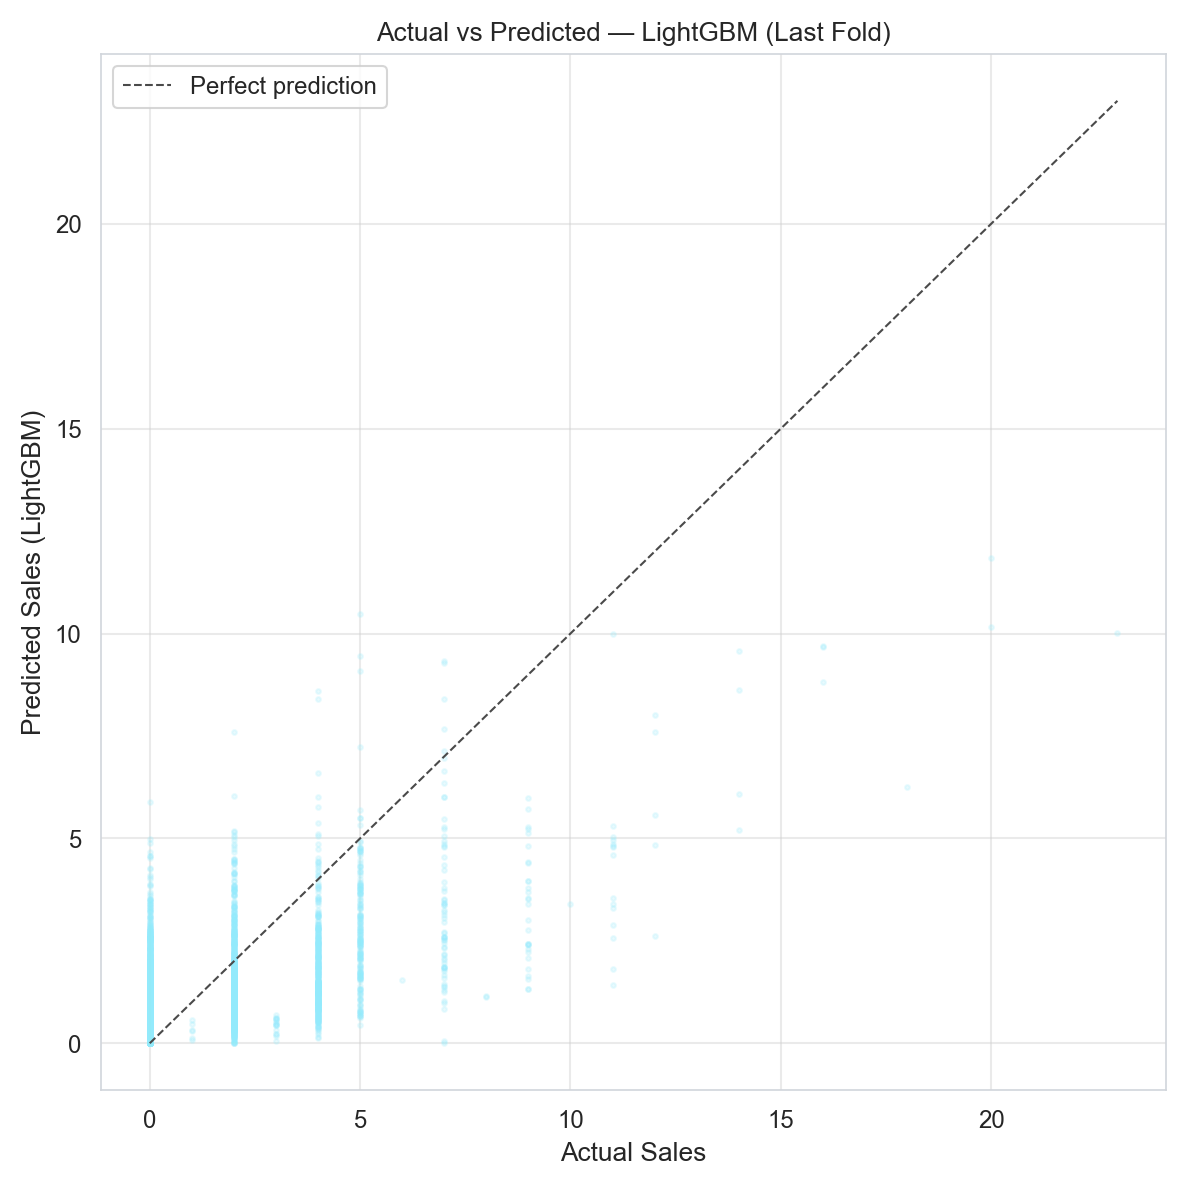

   → Saved 13_actual_vs_predicted_lgbm.png

MODELLING COMPLETE


In [9]:
print('\n' + '=' * 60)
print('9. GENERATING PLOTS')
print('=' * 60)

# 9.1 Model comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE', 'sigma_e']):
    vals = summary[metric].sort_values()
    colors = [ACCENT if v == vals.min() else PRIMARY for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel(metric)
plt.suptitle('Model Comparison \u2014 Average Across Folds', fontsize=14)
save_fig('11_model_comparison')

# 9.2 Feature importance
importance = pd.Series(lgb_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 8))
importance.sort_values().plot(kind='barh', ax=ax, color=PRIMARY)
ax.set_title('LightGBM Feature Importance (Top 20)')
ax.set_xlabel('Importance (split count)')
save_fig('12_lgbm_feature_importance')

# 9.3 Actual vs Predicted
if all_predictions:
    sample = pred_final.sample(min(5000, len(pred_final)), random_state=42)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(sample[TARGET], sample['LightGBM'], alpha=0.2, s=5, color=get_model_color('LightGBM'))
    lim = max(sample[TARGET].max(), sample['LightGBM'].max())
    ax.plot([0, lim], [0, lim], color=ALERT, linestyle='--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales (LightGBM)')
    ax.set_title('Actual vs Predicted \u2014 LightGBM (Last Fold)')
    ax.legend()
    save_fig('13_actual_vs_predicted_lgbm')

print('\n' + '=' * 60)
print('MODELLING COMPLETE')
print('=' * 60)
